<a href="https://colab.research.google.com/github/gabcsx/CCDATSCL_EXERCISES_COM221ML/blob/main/Exercise5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5

In [80]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import chi2_contingency


## Part 1: ANOVA

A teacher wants to investigate whether different teaching methods affect students’ exam scores. The dataset contains 50 students, each assigned to one of three teaching methods (A, B, or C).

Question: "Is there a difference in mean exam scores among students taught using three different teaching methods?"

- Independent variable (factor): Teaching Method (A, B, C)
- Dependent variable: Exam Score (numeric)

In [81]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/exam_scores.csv?raw=true"

df_exam_scores = pd.read_csv(url)
df_exam_scores


,StudentID,Method,Score
0,1,A,79
1,2,A,77
2,3,A,82
3,4,A,75
4,5,A,80
5,6,A,78
6,7,A,83
7,8,A,76
8,9,A,81
9,10,A,74


Calculate the number of students in each teaching method.

In [82]:
# Count students per teaching method
print("Number of students per teaching method:")
print(df_exam_scores['Method'].value_counts().sort_index())

Number of students per teaching method:
Method
A    17
B    17
C    16
Name: count, dtype: int64


Compute the mean and standard deviation of exam scores for each group.

In [83]:
group_stats = df_exam_scores.groupby('Method')['Score'].agg(['mean', 'std'])

print("Mean and standard deviation of exam scores by teaching method:")
print(group_stats)


Mean and standard deviation of exam scores by teaching method:
             mean       std
Method                     
A       78.588235  2.575336
B       86.294118  2.365500
C       71.937500  1.768945


Use a plot to show the exam scores by teaching method.

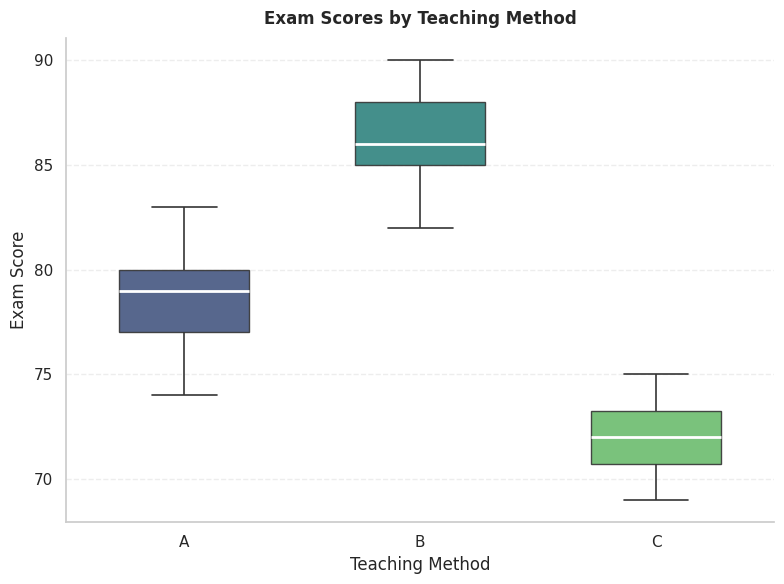

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_exam_scores,
    x="Method", y="Score",
    hue="Method", palette="viridis",
    legend=False, width=0.55,
    medianprops={"color": "white", "linewidth": 2},
    boxprops={"alpha": 0.9},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2}
)

plt.title("Exam Scores by Teaching Method", pad=10, weight="bold")
plt.xlabel("Teaching Method")
plt.ylabel("Exam Score")
plt.grid(axis="y", linestyle="--", alpha=0.35)
sns.despine()
plt.tight_layout()
plt.show()


Perform the ANOVA Test
- Use scipy.stats.f_oneway to conduct a one-way ANOVA.
- Report the F-statistic and p-value.
- Using a significance level of α = 0.05, state whether you reject or fail to reject H₀.

In [85]:
a = df_exam_scores.loc[df_exam_scores["Method"] == "A", "Score"]
b = df_exam_scores.loc[df_exam_scores["Method"] == "B", "Score"]
c = df_exam_scores.loc[df_exam_scores["Method"] == "C", "Score"]

F, p = stats.f_oneway(a, b, c)

alpha = 0.05
decision = "Reject H0" if p < alpha else "Fail to reject H0"

print(f"ANOVA results -> F={F:.4f}, p={p:.6g}, alpha={alpha}")
print(f"Decision: {decision}")
print("Meaning: average exam scores are not all the same across teaching methods." if p < alpha
      else "Meaning: no evidence of different average exam scores across methods.")


ANOVA results -> F=165.1785, p=5.50326e-22, alpha=0.05
Decision: Reject H0
Meaning: average exam scores are not all the same across teaching methods.


Interpret the results. What does it say about the relationship between teaching method and exam scores?

**INTERPRETATION:** Since the p-value is far below 0.05, we reject H₀. This indicates that mean exam scores differ across teaching methods (at least one method’s average is different).

## Part 2: Chi-squared

A survey was conducted to see if there is a relationship between gender and littering behavior.

Question:
"Is gender associated with littering behavior?"

Each row represents one person.

In [86]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/litteringdata.csv?raw=true"

df_littering_data = pd.read_csv(url)
df_littering_data

,ID,Gender,Litter
0,1,Male,Yes
1,2,Male,Yes
2,3,Male,Yes
3,4,Male,Yes
4,5,Male,Yes
5,6,Male,Yes
6,7,Male,Yes
7,8,Male,Yes
8,9,Male,Yes
9,10,Male,Yes


Count the number of observations in each category for Gender and Litter separately.

In [87]:
print("Counts for Gender:")
print(df_littering_data["Gender"].value_counts(dropna=False))

print("\nCounts for Litter:")
print(df_littering_data["Litter"].value_counts(dropna=False))

Counts for Gender:
Gender
Male      20
Female    20
Name: count, dtype: int64

Counts for Litter:
Litter
No     22
Yes    18
Name: count, dtype: int64


Using `pd.crosstab()`, create a contingency table showing counts of littering behavior for each gender.
- Write down the row totals, column totals, and grand total from the table.

In [88]:
# Contingency table: Gender x Litter
contingency_table = pd.crosstab(df_littering_data["Gender"], df_littering_data["Litter"])

print("Contingency Table (Observed Counts):")
print(contingency_table)

# Totals
row_totals = contingency_table.sum(axis=1)
col_totals = contingency_table.sum(axis=0)
grand_total = contingency_table.values.sum()

print("\nRow Totals:")
print(row_totals)

print("\nColumn Totals:")
print(col_totals)

print(f"\nGrand Total: {grand_total}")


Contingency Table (Observed Counts):
Litter  No  Yes
Gender         
Female  14    6
Male     8   12

Row Totals:
Gender
Female    20
Male      20
dtype: int64

Column Totals:
Litter
No     22
Yes    18
dtype: int64

Grand Total: 40


State the null hypothesis (H₀) and alternative hypothesis (H₁) for this chi-squared test.

**Null hypothesis (H₀):** Gender and littering behavior are independent (the proportion who litter is the same for males and females).

**Alternative hypothesis (H₁):** Gender and littering behavior are not independent (the proportion who litter differs by gender; there is an association).

Use scipy.stats.chi2_contingency to calculate:
- Chi-squared statistic
- p-value
- Degrees of freedom

Using a significance level of `α = 0.05`, determine whether to reject or fail to reject H₀.


In [89]:
ct = np.asarray(contingency_table)

# Basic validation
if ct.ndim != 2:
    raise ValueError("contingency_table must be a 2D array/table of observed counts.")
if ct.sum() == 0:
    raise ValueError("contingency_table sums to 0 (all zeros). Fill it with your observed counts.")
if (ct < 0).any():
    raise ValueError("contingency_table contains negative counts (not allowed).")

chi2, p_value, dof, expected = chi2_contingency(ct)

print(f"Chi-squared statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:\n", expected)

alpha = 0.05
print(f"\nSignificance level (alpha): {alpha}")

if p_value < alpha:
    print("Decision: Reject H0")
    print("Interpretation: There is statistically significant evidence that gender and littering behavior are associated.")
else:
    print("Decision: Fail to reject H0")
    print("Interpretation: There is not enough statistically significant evidence that gender and littering behavior are associated.")


Chi-squared statistic: 2.5253
p-value: 0.1120
Degrees of freedom: 1
Expected frequencies:
 [[11.  9.]
 [11.  9.]]

Significance level (alpha): 0.05
Decision: Fail to reject H0
Interpretation: There is not enough statistically significant evidence that gender and littering behavior are associated.


Interpret your results. Is there evidence that gender and littering behavior are associated?

At the 0.05 significance level, since the p-value (0.1120) is greater than alpha = 0.05, we fail to reject H₀. Therefore, there is not enough statistically significant evidence to conclude that gender and littering behavior are associated.